# 拉曼光谱数据增强效果查看器

这个 notebook 复用训练阶段相同的项目函数，用来查看 `dataset/细菌/init` 下原始 `.arc_data` 光谱经过预处理和数据增强后的变化。

这里展示的流程是：init `.arc_data` -> 预处理 -> 标准化前增强 -> 标准化 -> 标准化后增强。

标准化前增强包括：分段增益、高斯噪声、坐标轴扰动、弱基线扰动、强基线扰动。标准化后增强包括：平移、峰展宽、局部衰减遮挡。

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "raman").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 这个 notebook 只使用 raman.data.augmentation 中基于 NumPy 的增强函数。
# 如果当前 Jupyter kernel 没有 PyTorch，这里提供一个仅用于导入的最小占位模块，
# 让 isinstance(x, torch.Tensor) 这类检查可以通过。
try:
    import torch  # noqa: F401
except ModuleNotFoundError:
    import types

    torch_stub = types.ModuleType("torch")
    torch_stub.__path__ = []

    class _TensorStub:
        pass

    torch_stub.Tensor = _TensorStub
    nn_stub = types.ModuleType("torch.nn")
    functional_stub = types.ModuleType("torch.nn.functional")
    nn_stub.functional = functional_stub
    torch_stub.nn = nn_stub
    sys.modules["torch"] = torch_stub
    sys.modules["torch.nn"] = nn_stub
    sys.modules["torch.nn.functional"] = functional_stub

from raman.config import config as train_config
from raman.data.build import DEFAULT_PIPELINE_CONFIG, _cosmic_ray_kwargs
from raman.data.augmentation import (
    AXIS_WARP_ALPHA,
    AXIS_WARP_BETA,
    BASELINE_FREQ_MAX,
    BASELINE_FREQ_MIN,
    BASELINE_LIN_MAX,
    BASELINE_LIN_MIN,
    BASELINE_SIN_MAX,
    BASELINE_SIN_MIN,
    BASELINE_STRONG_AMP_MAX,
    BASELINE_STRONG_AMP_MIN,
    BROAD_SIGMA_MAX,
    BROAD_SIGMA_MIN,
    BROAD_TRUNCATE,
    MASK_ATTEN_MAX,
    MASK_ATTEN_MIN,
    MASK_WIDTH_MAX,
    MASK_WIDTH_MIN,
    NOISE_BASE_REL_MAX,
    NOISE_BASE_REL_MIN,
    NOISE_SLOPE_REL_MAX,
    NOISE_SLOPE_REL_MIN,
    PIECEWISE_GAIN_STD,
    SHIFT_MAX,
    _random_piecewise_segments,
    aug_axis_warp,
    aug_broadening,
    aug_mask_attenuate,
    aug_noise_gaussian,
    aug_piecewise_gain,
    aug_shift,
    aug_strong_baseline,
    aug_weak_baseline,
    augment_norm_spectrum,
    augment_raw_spectrum,
)
from raman.data.normalization import normalize_spectrum
from raman.data.preprocess import preprocess_single_spectrum
from raman.data.profiles import PROFILES
from raman.data.spectrum_io import read_arc_data

中文字体候选 = [
    "Microsoft YaHei",
    "SimHei",
    "SimSun",
    "Noto Sans CJK SC",
    "Source Han Sans SC",
    "Arial Unicode MS",
]
已安装字体 = {font.name for font in font_manager.fontManager.ttflist}
for 字体名 in 中文字体候选:
    if 字体名 in 已安装字体:
        plt.rcParams["font.sans-serif"] = [字体名] + plt.rcParams.get("font.sans-serif", [])
        print("绘图中文字体:", 字体名)
        break
else:
    print("未找到常见中文字体；如果图中文字显示为方块，请在系统或当前环境安装中文字体。")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

INIT_ROOT = PROJECT_ROOT / "dataset" / "细菌" / "init"
PIPELINE_CFG = DEFAULT_PIPELINE_CONFIG
PROFILE = PROFILES["bacteria"]

print("项目根目录:", PROJECT_ROOT)
print("init 数据目录:", INIT_ROOT)
print("预处理波数范围:", PIPELINE_CFG.cut_min, "到", PIPELINE_CFG.cut_max, "cm^-1")
print("去除坏波段前的目标点数:", PIPELINE_CFG.target_points)
print("坏波段:", PIPELINE_CFG.bad_bands)
print("标准化方法:", train_config.norm_method)
print("最大平移点数:", SHIFT_MAX)

绘图中文字体: Microsoft YaHei
项目根目录: E:\Pythonproject\拉曼光谱分类
init 数据目录: E:\Pythonproject\拉曼光谱分类\dataset\细菌\init
预处理波数范围: 600 到 1800 cm^-1
去除坏波段前的目标点数: 896
坏波段: ((890.0, 950.0),)
标准化方法: snv
最大平移点数: 3


## 选择一条 init 光谱

默认随机选择一条。若要固定样本，可以设置 `SAMPLE_PATH`；若要在匹配结果里按序号选择，可以设置 `SAMPLE_INDEX`；若要先按关键词筛选，可以设置 `SAMPLE_CONTAINS`。

In [8]:
SAMPLE_INDEX = None    # 设为整数时，从匹配结果中按序号选择；为 None 时随机选择
SAMPLE_CONTAINS = None # 示例："Acinetobacter" 或 "cell10"；为 None 时不筛选
SAMPLE_PATH = None     # 示例：INIT_ROOT / "Acinetobacter" / "AB01" / "cell10_Area01_000_shift.arc_data"
RANDOM_SEED = None     # 设为整数可复现随机选择；为 None 时每次随机

def list_init_files(root=INIT_ROOT, contains=None):
    files = sorted(root.rglob("*.arc_data"))
    if contains:
        files = [p for p in files if contains.lower() in str(p).lower()]
    return files

files = list_init_files(contains=SAMPLE_CONTAINS)
if not files:
    raise FileNotFoundError(f"在 {INIT_ROOT} 下没有找到 .arc_data 文件")

if SAMPLE_PATH is not None:
    sample_path = Path(SAMPLE_PATH)
elif SAMPLE_INDEX is not None:
    sample_path = files[int(SAMPLE_INDEX)]
else:
    rng = np.random.default_rng(RANDOM_SEED)
    sample_path = files[int(rng.integers(0, len(files)))]
print("匹配文件数:", len(files))
print("当前选择:", sample_path)

for idx, path in enumerate(files[:10]):
    print(f"{idx:>2}: {path.relative_to(INIT_ROOT)}")

匹配文件数: 6526
当前选择: E:\Pythonproject\拉曼光谱分类\dataset\细菌\init\Burkholderia\BCC04\cell7_Area01_001_shift.arc_data
 0: Acinetobacter\AB01\cell10_Area01_000_shift.arc_data
 1: Acinetobacter\AB01\cell10_Area01_001_shift.arc_data
 2: Acinetobacter\AB01\cell11_Area01_000_shift.arc_data
 3: Acinetobacter\AB01\cell12_Area01_000_shift.arc_data
 4: Acinetobacter\AB01\cell12_Area01_001_shift.arc_data
 5: Acinetobacter\AB01\cell13_Area01_000_shift.arc_data
 6: Acinetobacter\AB01\cell13_Area01_001_shift.arc_data
 7: Acinetobacter\AB01\cell14_Area01_000_shift.arc_data
 8: Acinetobacter\AB01\cell14_Area01_001_shift.arc_data
 9: Acinetobacter\AB01\cell15_Area01_000_shift.arc_data


In [9]:
def add_nan_gaps(wn, *ys):
    wn = np.asarray(wn, dtype=np.float32)
    ys = [np.asarray(y, dtype=np.float32) for y in ys]
    if wn.size < 2:
        return (wn, *ys)
    diffs = np.diff(wn)
    normal_step = np.median(diffs[diffs > 0])
    gap_mask = diffs > normal_step * 3.0
    if not gap_mask.any():
        return (wn, *ys)

    wn_out = []
    y_out = [[] for _ in ys]
    for i in range(len(wn)):
        wn_out.append(float(wn[i]))
        for dst, y in zip(y_out, ys):
            dst.append(float(y[i]))
        if i < len(wn) - 1 and gap_mask[i]:
            wn_out.append(float((wn[i] + wn[i + 1]) / 2.0))
            for dst in y_out:
                dst.append(np.nan)
    return (np.asarray(wn_out), *[np.asarray(y) for y in y_out])


def preprocess_init_file(path):
    wn, sp = read_arc_data(path)
    wn_ref = PIPELINE_CFG.build_wn_ref()
    wn_p, sp_p, cosmic = preprocess_single_spectrum(
        wn,
        sp,
        cut_min=PIPELINE_CFG.cut_min,
        cut_max=PIPELINE_CFG.cut_max,
        wn_ref=wn_ref,
        bad_bands=PIPELINE_CFG.bad_bands,
        baseline_method=PIPELINE_CFG.baseline_method,
        baseline_lam=PIPELINE_CFG.baseline_lam,
        baseline_asls_p=PIPELINE_CFG.baseline_asls_p,
        baseline_max_iter=PIPELINE_CFG.baseline_max_iter,
        baseline_fit_min=PIPELINE_CFG.baseline_fit_min,
        baseline_fit_max=PIPELINE_CFG.baseline_fit_max,
        **_cosmic_ray_kwargs(PROFILE, PIPELINE_CFG),
    )
    if wn_p is None:
        raise ValueError(f"预处理失败: {path}")
    return {
        "path": Path(path),
        "raw_wn": wn,
        "raw_sp": sp,
        "wn": wn_p,
        "preprocessed": sp_p.astype(np.float32),
        "cosmic": cosmic,
    }


def make_training_style_trace(path, seed=7):
    np.random.seed(seed)
    rec = preprocess_init_file(path)
    raw = rec["preprocessed"]
    raw_aug = augment_raw_spectrum(raw, train_config)
    norm_base = normalize_spectrum(raw, train_config.norm_method)
    norm_after_raw_aug = normalize_spectrum(raw_aug, train_config.norm_method)
    final_aug = augment_norm_spectrum(norm_after_raw_aug, train_config)
    rec.update(
        raw_aug=raw_aug,
        norm_base=norm_base,
        norm_after_raw_aug=norm_after_raw_aug,
        final_aug=final_aug,
        seed=seed,
    )
    return rec


def summary(trace):
    wn = trace["wn"]
    step = float(np.median(np.diff(wn)))
    print("文件:", trace["path"].relative_to(INIT_ROOT))
    print("预处理后点数:", len(trace["preprocessed"]))
    print("每个点约对应波数:", round(step, 4), "cm^-1")
    print("平移范围约:", round(-SHIFT_MAX * step, 3), "到", round(SHIFT_MAX * step, 3), "cm^-1")
    print("宇宙射线替换点数:", int(trace["cosmic"]))

## 按训练顺序查看完整增强链路

这个单元展示主通道在 `build_model_input(..., augment=True)` 中使用的实际顺序。

文件: Burkholderia\BCC04\cell7_Area01_001_shift.arc_data
预处理后点数: 851
每个点约对应波数: 1.3408 cm^-1
平移范围约: -4.022 到 4.022 cm^-1
宇宙射线替换点数: 27


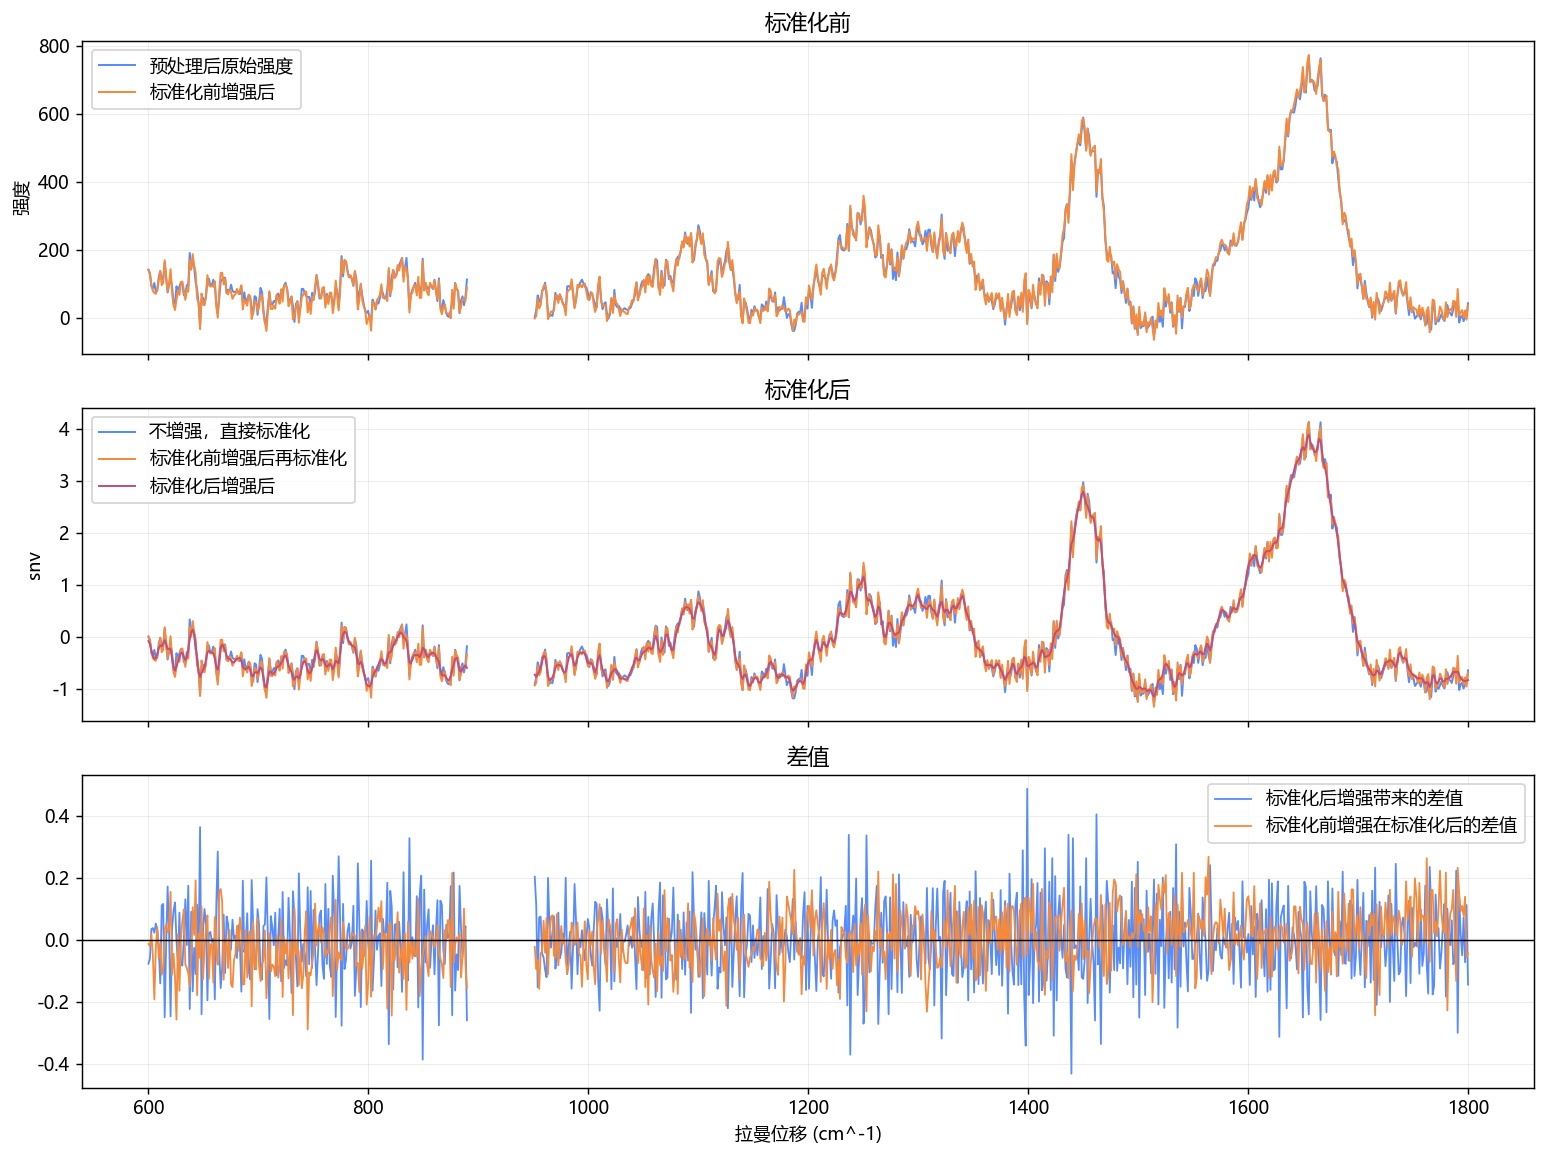

In [14]:
SEED = None
trace = make_training_style_trace(sample_path, seed=SEED)
summary(trace)

wn, raw, raw_aug = add_nan_gaps(trace["wn"], trace["preprocessed"], trace["raw_aug"])
_, norm_base, norm_after_raw, final_aug = add_nan_gaps(
    trace["wn"], trace["norm_base"], trace["norm_after_raw_aug"], trace["final_aug"]
)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(wn, raw, lw=1.1, label="预处理后原始强度")
axes[0].plot(wn, raw_aug, lw=1.1, label="标准化前增强后")
axes[0].set_title("标准化前")
axes[0].set_ylabel("强度")
axes[0].legend()

axes[1].plot(wn, norm_base, lw=1.1, label="不增强，直接标准化")
axes[1].plot(wn, norm_after_raw, lw=1.1, label="标准化前增强后再标准化")
axes[1].plot(wn, final_aug, lw=1.1, label="标准化后增强后")
axes[1].set_title("标准化后")
axes[1].set_ylabel(train_config.norm_method)
axes[1].legend()

axes[2].plot(wn, final_aug - norm_after_raw, lw=1.0, label="标准化后增强带来的差值")
axes[2].plot(wn, norm_after_raw - norm_base, lw=1.0, label="标准化前增强在标准化后的差值")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("差值")
axes[2].set_xlabel("拉曼位移 (cm^-1)")
axes[2].legend()

fig.tight_layout()

## 多次随机抽样查看增强分布

这个单元用当前 `raman/config.py` 里的概率参数，多次随机生成增强结果，方便观察扰动幅度。

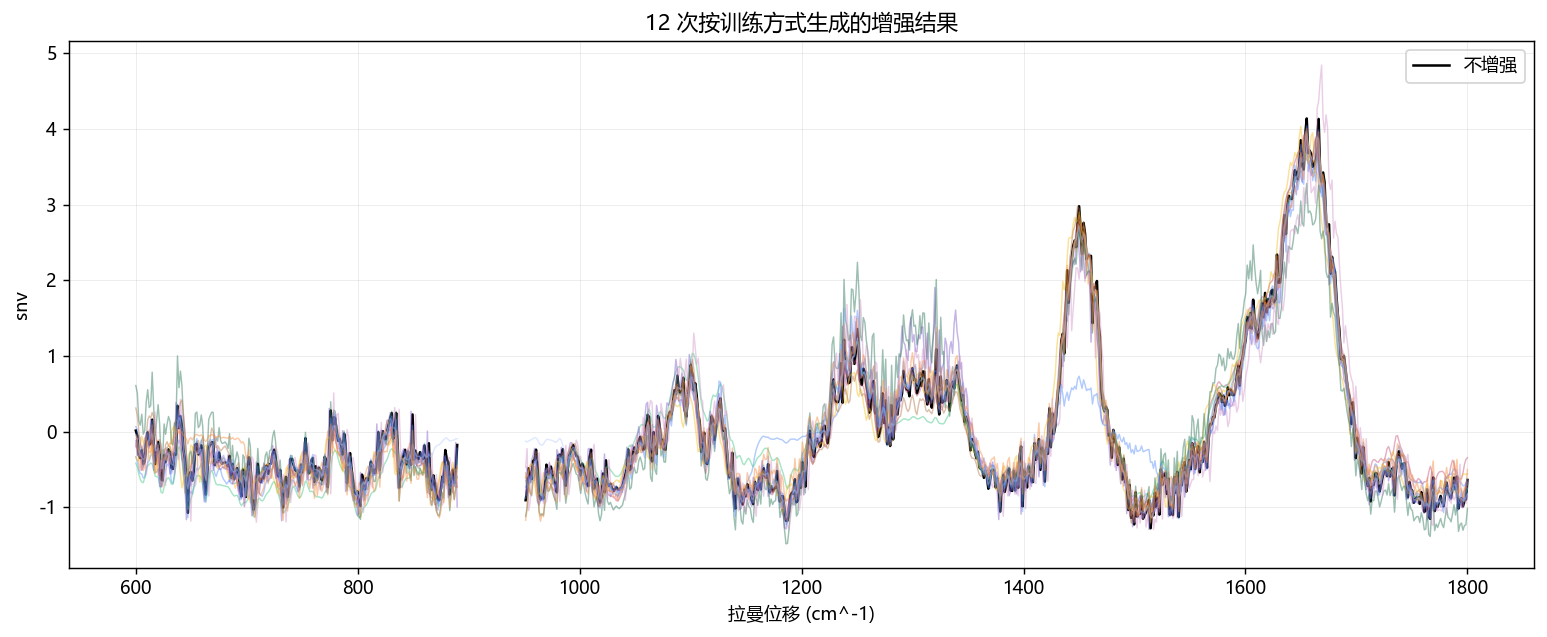

In [15]:
N_DRAWS = 12
SEED_START = 100

base = preprocess_init_file(sample_path)
base_norm = normalize_spectrum(base["preprocessed"], train_config.norm_method)
draws = [make_training_style_trace(sample_path, seed=SEED_START + i) for i in range(N_DRAWS)]

wn_plot, base_plot = add_nan_gaps(base["wn"], base_norm)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wn_plot, base_plot, color="black", lw=1.4, label="不增强")
for item in draws:
    w, y = add_nan_gaps(item["wn"], item["final_aug"])
    ax.plot(w, y, lw=0.8, alpha=0.45)
ax.set_title(f"{N_DRAWS} 次按训练方式生成的增强结果")
ax.set_xlabel("拉曼位移 (cm^-1)")
ax.set_ylabel(train_config.norm_method)
ax.legend()
fig.tight_layout()

## 单独查看每一种增强算子

这些图会把每一种增强单独拆开看。标准化前增强作用在预处理后的强度上；标准化后增强作用在已经标准化的谱上。

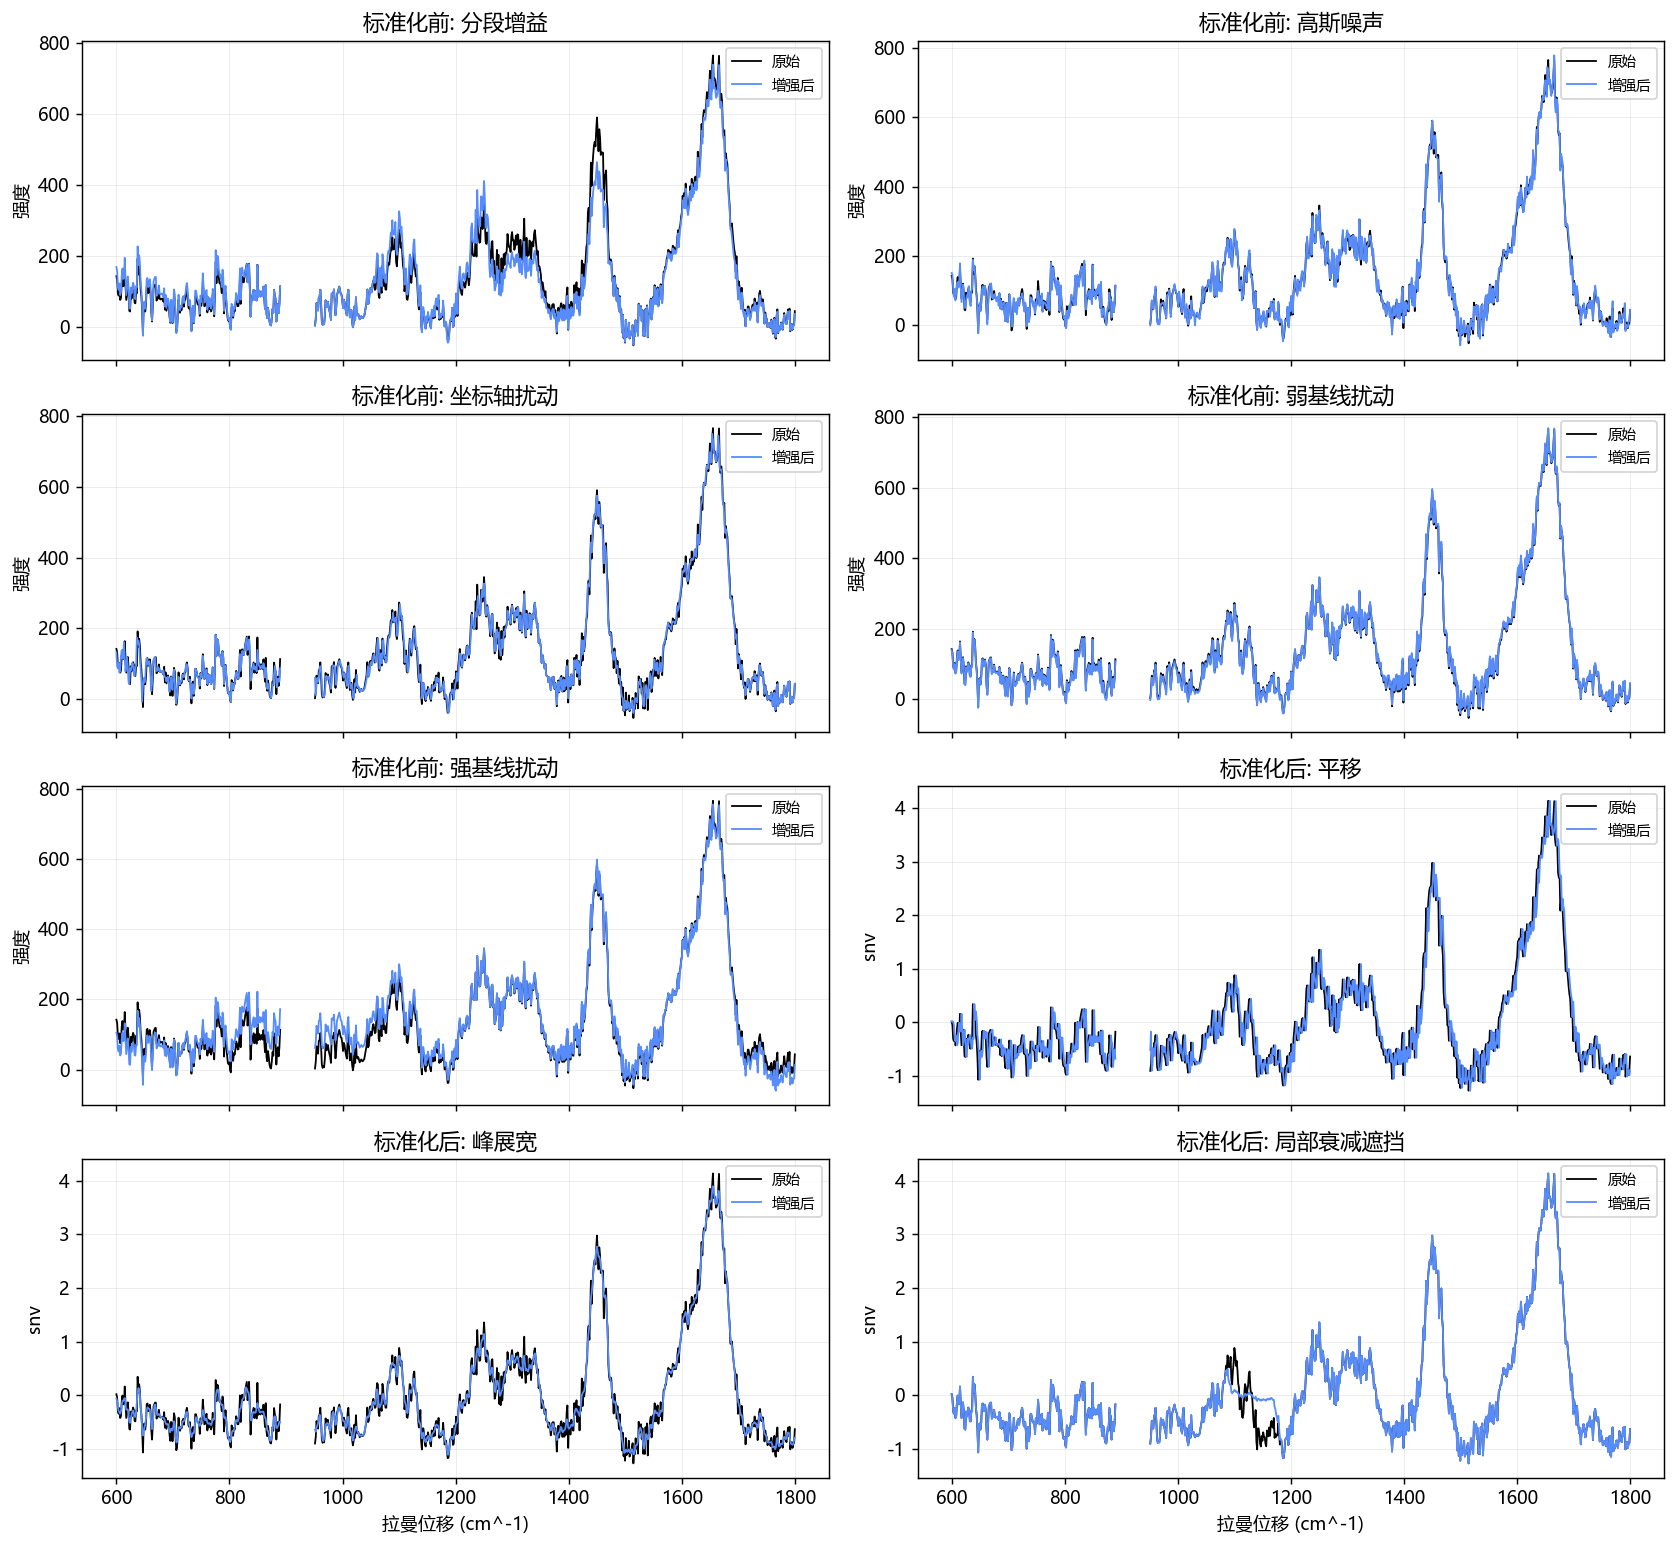

In [13]:
def individual_operator_examples(path, seed=123):
    np.random.seed(seed)
    rec = preprocess_init_file(path)
    raw = rec["preprocessed"]
    norm = normalize_spectrum(raw, train_config.norm_method)

    segments = _random_piecewise_segments(len(raw), min_len=60, max_len=180)
    raw_ops = {
        "分段增益": aug_piecewise_gain(raw, segments, gain_std=PIECEWISE_GAIN_STD),
        "高斯噪声": aug_noise_gaussian(
            raw,
            base_rel_min=NOISE_BASE_REL_MIN,
            base_rel_max=NOISE_BASE_REL_MAX,
            slope_rel_min=NOISE_SLOPE_REL_MIN,
            slope_rel_max=NOISE_SLOPE_REL_MAX,
        ),
        "坐标轴扰动": aug_axis_warp(raw),
        "弱基线扰动": aug_weak_baseline(
            raw,
            lin_min=BASELINE_LIN_MIN,
            lin_max=BASELINE_LIN_MAX,
            sin_min=BASELINE_SIN_MIN,
            sin_max=BASELINE_SIN_MAX,
            freq_min=BASELINE_FREQ_MIN,
            freq_max=BASELINE_FREQ_MAX,
        ),
        "强基线扰动": aug_strong_baseline(
            raw,
            amp_min=BASELINE_STRONG_AMP_MIN,
            amp_max=BASELINE_STRONG_AMP_MAX,
        ),
    }

    post_ops = {
        "平移": aug_shift(norm, SHIFT_MAX),
        "峰展宽": aug_broadening(norm, BROAD_SIGMA_MIN, BROAD_SIGMA_MAX, BROAD_TRUNCATE),
        "局部衰减遮挡": aug_mask_attenuate(
            norm,
            width_min=MASK_WIDTH_MIN,
            width_max=MASK_WIDTH_MAX,
            atten_min=MASK_ATTEN_MIN,
            atten_max=MASK_ATTEN_MAX,
        ),
    }
    return rec, raw_ops, norm, post_ops


rec, raw_ops, norm_base, post_ops = individual_operator_examples(sample_path, seed=123)
ops = [("标准化前: " + name, rec["preprocessed"], value, "强度") for name, value in raw_ops.items()]
ops += [("标准化后: " + name, norm_base, value, train_config.norm_method) for name, value in post_ops.items()]

fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
axes = axes.ravel()
for ax, (title, baseline, augmented, ylabel) in zip(axes, ops):
    w, b, a = add_nan_gaps(rec["wn"], baseline, augmented)
    ax.plot(w, b, color="black", lw=1.0, label="原始")
    ax.plot(w, a, lw=1.0, label="增强后")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

for ax in axes[len(ops):]:
    ax.axis("off")

for ax in axes[-2:]:
    ax.set_xlabel("拉曼位移 (cm^-1)")

fig.tight_layout()

## 当前增强参数

这里列出当前训练配置和增强常量，方便对照上面的图。

In [ ]:
params = {
    "p_piecewise_gain": train_config.p_piecewise_gain,
    "p_noise": train_config.p_noise,
    "p_axis": train_config.p_axis,
    "p_baseline_weak": train_config.p_baseline_weak,
    "p_baseline_strong": train_config.p_baseline_strong,
    "max_pre_augs": train_config.max_pre_augs,
    "p_shift": train_config.p_shift,
    "p_broadening": train_config.p_broadening,
    "p_cut": train_config.p_cut,
    "max_post_augs": train_config.max_post_augs,
    "SHIFT_MAX_points": SHIFT_MAX,
    "BROAD_SIGMA_MIN": BROAD_SIGMA_MIN,
    "BROAD_SIGMA_MAX": BROAD_SIGMA_MAX,
    "MASK_WIDTH_MIN_points": MASK_WIDTH_MIN,
    "MASK_WIDTH_MAX_points": MASK_WIDTH_MAX,
    "MASK_ATTEN_MIN": MASK_ATTEN_MIN,
    "MASK_ATTEN_MAX": MASK_ATTEN_MAX,
    "AXIS_WARP_ALPHA": AXIS_WARP_ALPHA,
    "AXIS_WARP_BETA": AXIS_WARP_BETA,
}

for key, value in params.items():
    print(f"{key:>24}: {value}")